In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
df=pd.read_csv('high_risk_pregnancy_realistic_2000 (1).csv')


In [3]:
df.shape

(2000, 24)

In [4]:
print("Duplicated rows : ",df.duplicated().sum())
print("Duplicate patient_ids:", df['patient_id'].duplicated().sum())

Duplicated rows :  0
Duplicate patient_ids: 40


In [5]:
patient_counts=df['patient_id'].value_counts()
print(patient_counts[patient_counts>1])

patient_id
HRP202600001    2
HRP202601904    2
HRP202601962    2
HRP202601773    2
HRP202600966    2
HRP202600955    2
HRP202600220    2
HRP202601209    2
HRP202600700    2
HRP202600323    2
HRP202600146    2
HRP202600327    2
HRP202600831    2
HRP202600423    2
HRP202601406    2
HRP202601715    2
HRP202600838    2
HRP202601660    2
HRP202601345    2
HRP202600111    2
HRP202601168    2
HRP202601120    2
HRP202600849    2
HRP202600663    2
HRP202601850    2
HRP202600134    2
HRP202601142    2
HRP202601148    2
HRP202601963    2
HRP202601435    2
HRP202601492    2
HRP202600271    2
HRP202601511    2
HRP202600251    2
HRP202600528    2
HRP202601981    2
HRP202601485    2
HRP202601746    2
HRP202601502    2
HRP202601503    2
Name: count, dtype: int64


In [6]:
df.head(10)

,timestamp,patient_id,device_source,village,age_years,gravida_G,para_P,live_child_L,abortion_A,death_D,...,body_temperature_F,heart_rate_bpm,hemoglobin_g_dL,hba1c_percent,respiratory_rate_bpm,bmi,spo2_percent,edema_severity,symptoms_score_0_10,risk_class
0,2026-01-01 08:55:00,HRP202600001,ANM Tablet,Nandgaon,35,3,2,2,0,1,...,99.4,85.3,10.6,7.2,23.4,16.0,96.3,Mild,4.4,Risk
1,2026-01-01 09:00:00,HRP202600002,ASHA Mobile,Lakshmipur,33,5,0,0,0,0,...,97.9,94.6,9.1,5.4,19.5,26.2,99.5,NaN,2.3,No Risk
2,2026-01-01 09:17:00,HRP202600003,ASHA Mobile,Haripur,28,1,0,0,1,0,...,99.6,86.8,11.7,6.7,19.5,30.8,98.7,Severe,0.4,No Risk
3,2026-01-01 09:57:00,HRP202600004,ASHA Mobile,Shivpuri,25,2,0,0,0,0,...,97.5,101.0,NaN,6.0,16.9,22.3,97.2,Mild,2.0,No Risk
4,2026-01-01 10:06:00,HRP202600005,PHC Kiosk,Madanpur,27,2,0,0,0,0,...,98.6,102.8,NaN,5.3,25.1,21.6,95.9,NaN,3.7,No Risk
5,2026-01-01 11:20:00,HRP202600001,ANM Tablet,Nandgaon,35,3,2,2,0,1,...,99.4,85.5,11.5,7.6,22.5,15.9,97.7,Mild,4.7,Risk
6,2026-01-01 11:26:00,HRP202600006,PHC Kiosk,Madanpur,24,3,2,0,0,0,...,99.5,102.4,10.8,4.9,21.8,34.1,99.2,NaN,6.3,No Risk
7,2026-01-01 11:55:00,HRP202600007,ASHA Mobile,Bhawanipur,18,2,0,0,0,0,...,97.8,81.4,8.6,6.0,20.4,31.8,99.9,NaN,0.0,No Risk
8,2026-01-01 13:01:00,HRP202600008,ANM Tablet,Shivpuri,25,3,2,2,1,0,...,98.5,81.3,11.2,4.8,19.7,26.8,99.1,NaN,0.0,No Risk
9,2026-01-01 13:02:00,HRP202600009,ANM Tablet,Haripur,29,3,0,0,0,0,...,99.2,98.5,10.3,5.1,17.1,21.1,NaN,NaN,1.8,No Risk


In [7]:
df.describe()

,age_years,gravida_G,para_P,live_child_L,abortion_A,death_D,gestational_age_weeks,systolic_bp_mmHg,diastolic_bp_mmHg,random_blood_sugar_mg_dL,body_temperature_F,heart_rate_bpm,hemoglobin_g_dL,hba1c_percent,respiratory_rate_bpm,bmi,spo2_percent,symptoms_score_0_10
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.0000,2000.00000,1959.000000,2000.000000,2000.000000,1878.000000,1942.000000,2000.00000,1899.000000,1839.000000,2000.000000,1940.000000,1921.000000,1937.000000
mean,27.250000,2.377500,0.676500,0.326000,0.2870,0.01250,24.112149,116.005700,74.854650,113.167146,98.420752,88.53695,10.807636,5.406417,19.040300,24.846443,97.741801,2.959628
std,5.657694,1.366355,0.986577,0.668541,0.5872,0.11113,8.443060,12.861973,9.071461,25.833885,0.710354,11.78776,1.422801,0.780678,2.792412,4.572314,1.206099,2.135549
min,18.000000,1.000000,0.000000,0.000000,0.0000,0.00000,5.000000,88.000000,50.000000,65.000000,96.500000,55.00000,6.300000,3.700000,12.000000,15.600000,89.000000,-2.000000
25%,23.000000,1.000000,0.000000,0.000000,0.0000,0.00000,17.900000,107.000000,69.000000,94.000000,97.900000,80.57500,9.900000,4.900000,17.100000,21.700000,96.900000,1.200000
50%,27.000000,2.000000,0.000000,0.000000,0.0000,0.00000,24.100000,115.700000,74.750000,113.650000,98.400000,88.50000,10.800000,5.400000,19.100000,24.900000,97.800000,2.800000
75%,31.000000,3.000000,1.000000,0.000000,0.0000,0.00000,30.000000,124.500000,81.000000,130.600000,98.900000,96.50000,11.800000,5.900000,20.900000,28.000000,98.600000,4.400000
max,44.000000,7.000000,5.000000,5.000000,3.0000,1.00000,40.000000,198.000000,126.000000,312.000000,103.400000,148.00000,15.200000,10.100000,31.000000,40.000000,100.500000,10.000000


In [8]:
df.columns.tolist()

['timestamp',
 'patient_id',
 'device_source',
 'village',
 'age_years',
 'gravida_G',
 'para_P',
 'live_child_L',
 'abortion_A',
 'death_D',
 'gestational_age_weeks',
 'systolic_bp_mmHg',
 'diastolic_bp_mmHg',
 'random_blood_sugar_mg_dL',
 'body_temperature_F',
 'heart_rate_bpm',
 'hemoglobin_g_dL',
 'hba1c_percent',
 'respiratory_rate_bpm',
 'bmi',
 'spo2_percent',
 'edema_severity',
 'symptoms_score_0_10',
 'risk_class']

### Missing values

In [9]:
missing=df.isnull().sum()   #to find number of missing values in each col.
missing_percent = (missing / len(df)) * 100    #percentage of missing values
print(missing_percent)

timestamp                    0.00
patient_id                   0.00
device_source                0.00
village                      0.00
age_years                    0.00
gravida_G                    0.00
para_P                       0.00
live_child_L                 0.00
abortion_A                   0.00
death_D                      0.00
gestational_age_weeks        2.05
systolic_bp_mmHg             0.00
diastolic_bp_mmHg            0.00
random_blood_sugar_mg_dL     6.10
body_temperature_F           2.90
heart_rate_bpm               0.00
hemoglobin_g_dL              5.05
hba1c_percent                8.05
respiratory_rate_bpm         0.00
bmi                          3.00
spo2_percent                 3.95
edema_severity              69.05
symptoms_score_0_10          3.15
risk_class                   0.00
dtype: float64


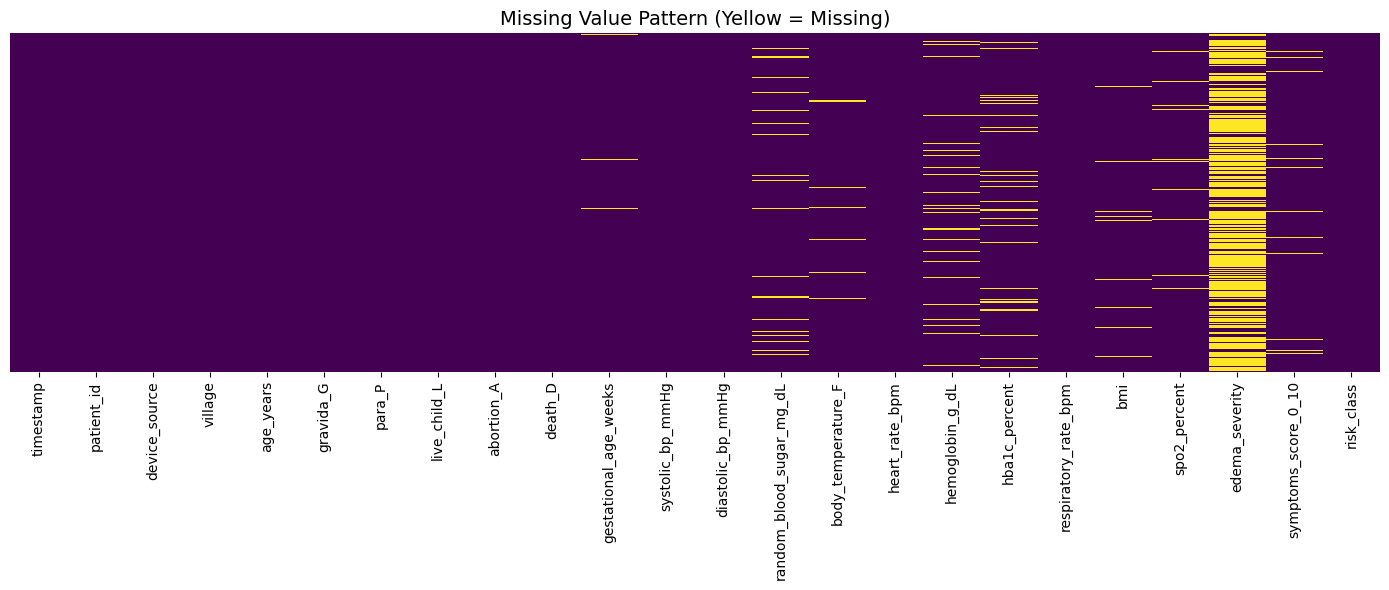

In [10]:
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Pattern (Yellow = Missing)', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
print(df['risk_class'].value_counts())
print(df['risk_class'].value_counts(normalize=True)*100)  #normalization = converts counts into proportion

risk_class
No Risk    1696
Risk        304
Name: count, dtype: int64
risk_class
No Risk    84.8
Risk       15.2
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Risk vs No-Risk')

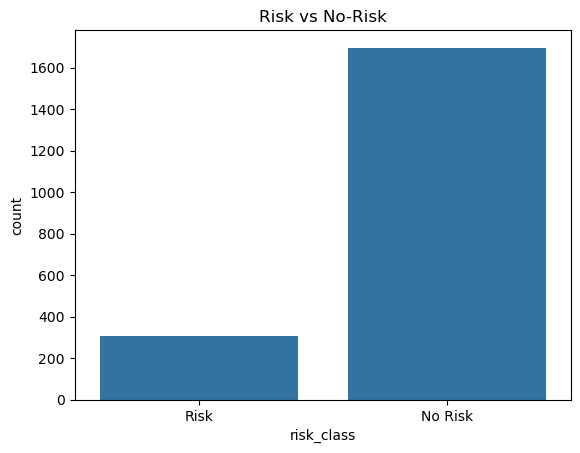

In [12]:
sns.countplot(x='risk_class',data=df)
plt.title('Risk vs No-Risk')


In [13]:
vitals = ['systolic_bp_mmHg', 'diastolic_bp_mmHg', 'heart_rate_bpm',
          'spo2_percent', 'body_temperature_F', 'respiratory_rate_bpm']
for col in vitals :
    print(f"-{col}:")
    print(f"  min : {df[col].min():.1f}")
    print(f"  max : {df[col].max():.1f}")
    print()

-systolic_bp_mmHg:
  min : 88.0
  max : 198.0

-diastolic_bp_mmHg:
  min : 50.0
  max : 126.0

-heart_rate_bpm:
  min : 55.0
  max : 148.0

-spo2_percent:
  min : 89.0
  max : 100.5

-body_temperature_F:
  min : 96.5
  max : 103.4

-respiratory_rate_bpm:
  min : 12.0
  max : 31.0



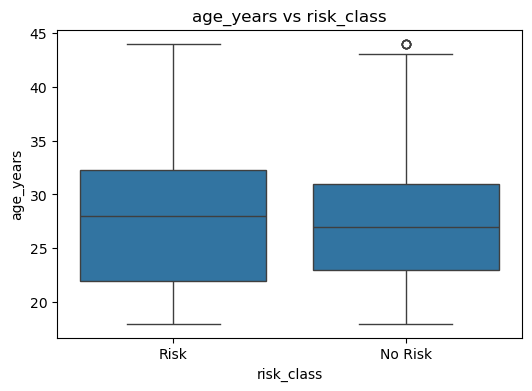

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x='risk_class',y='age_years',data=df)
plt.title('age_years vs risk_class')
plt.show()

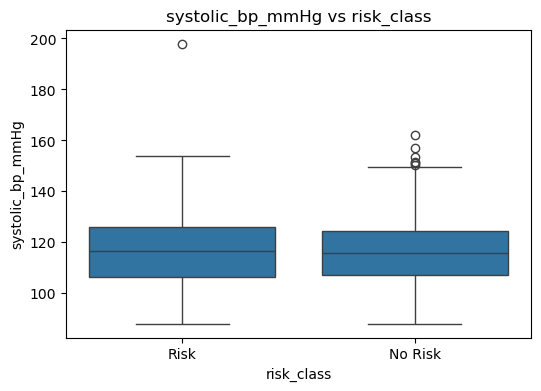

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x='risk_class',y='systolic_bp_mmHg',data=df)
plt.title('systolic_bp_mmHg vs risk_class')
plt.show()

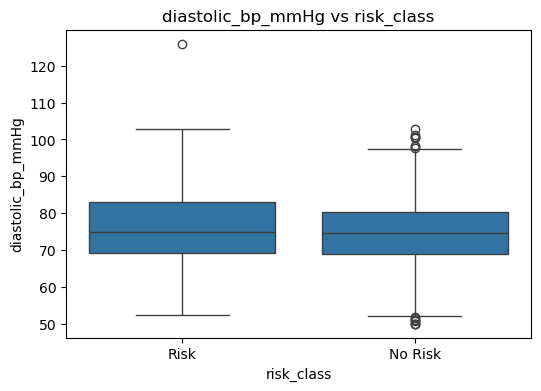

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x='risk_class',y='diastolic_bp_mmHg',data=df)
plt.title('diastolic_bp_mmHg vs risk_class')
plt.show()

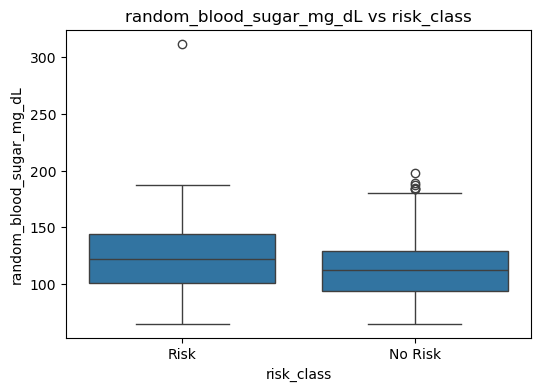

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x='risk_class',y='random_blood_sugar_mg_dL',data=df)
plt.title('random_blood_sugar_mg_dL vs risk_class')
plt.show()

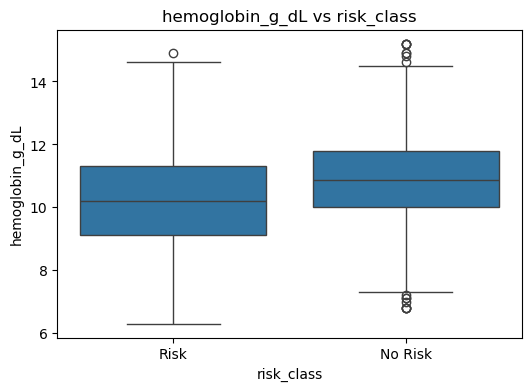

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x='risk_class',y='hemoglobin_g_dL',data=df)
plt.title('hemoglobin_g_dL vs risk_class')
plt.show()

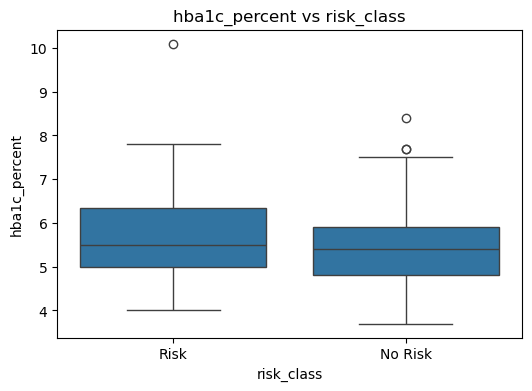

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x='risk_class',y='hba1c_percent',data=df)
plt.title('hba1c_percent vs risk_class')
plt.show()

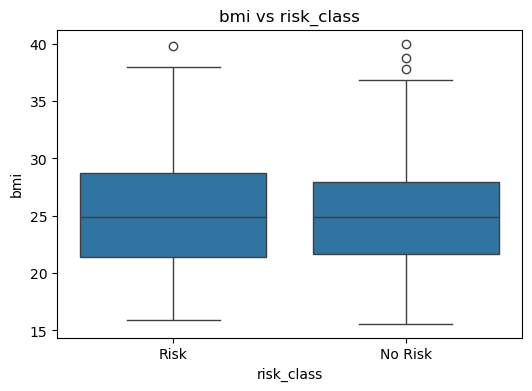

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(x='risk_class',y='bmi',data=df)
plt.title('bmi vs risk_class')
plt.show()

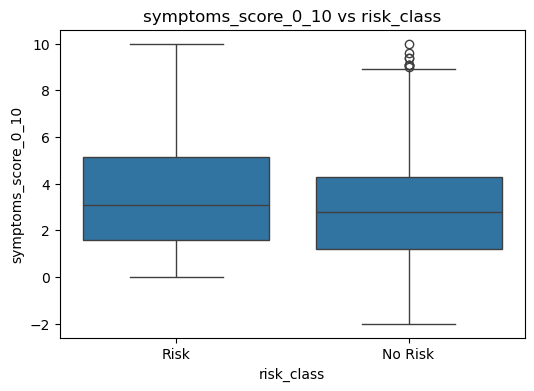

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x='risk_class',y='symptoms_score_0_10',data=df)
plt.title('symptoms_score_0_10 vs risk_class')
plt.show()

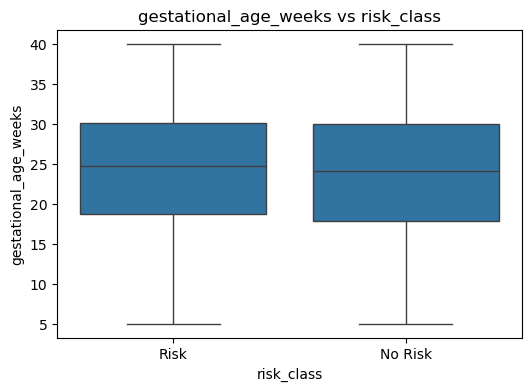

In [22]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='risk_class', y='gestational_age_weeks',data=df)
plt.title('gestational_age_weeks vs risk_class')
plt.show()

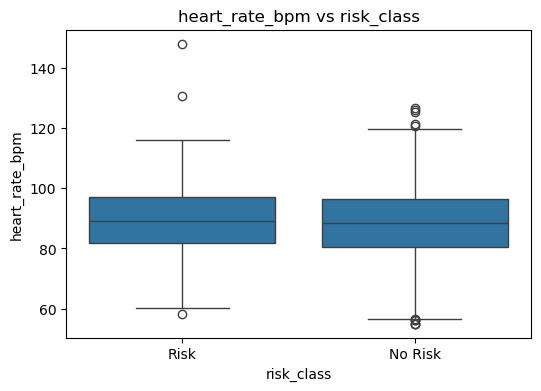

In [23]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='risk_class', y='heart_rate_bpm', data=df)
plt.title('heart_rate_bpm vs risk_class')
plt.show()

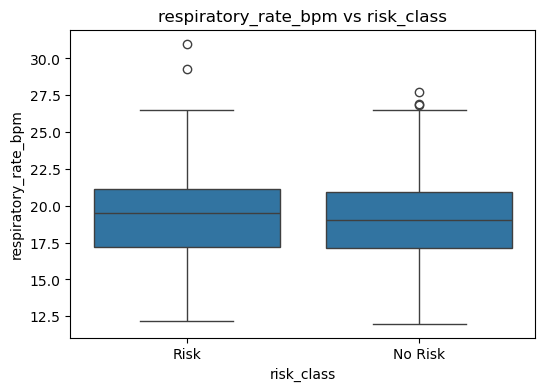

In [24]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='risk_class', y='respiratory_rate_bpm', data=df)
plt.title('respiratory_rate_bpm vs risk_class')
plt.show()

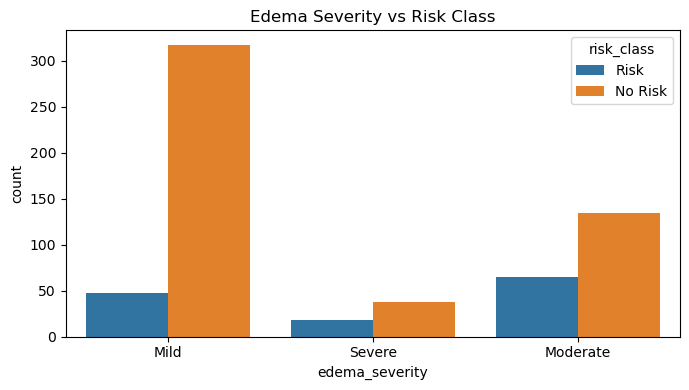

In [25]:
plt.figure(figsize=(7, 4))
sns.countplot(x='edema_severity', hue='risk_class', data=df)
plt.title('Edema Severity vs Risk Class')
plt.tight_layout()
plt.show()

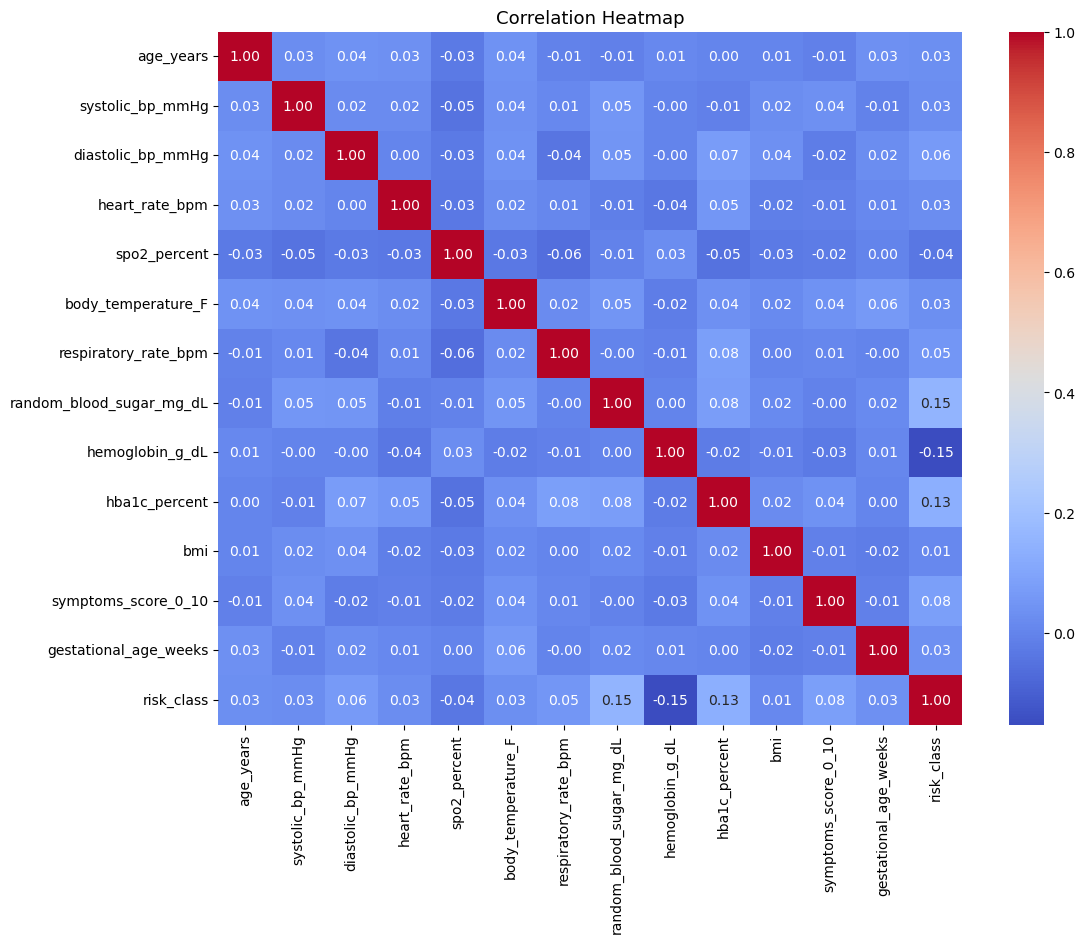

In [34]:
df_corr = df.copy()
df_corr['risk_class'] = df_corr['risk_class'].map({'No Risk': 0, 'Risk': 1})
num_cols = ['age_years', 'systolic_bp_mmHg', 'diastolic_bp_mmHg',
            'heart_rate_bpm', 'spo2_percent', 'body_temperature_F',
            'respiratory_rate_bpm', 'random_blood_sugar_mg_dL',
            'hemoglobin_g_dL', 'hba1c_percent', 'bmi',
            'symptoms_score_0_10', 'gestational_age_weeks']

corr = df_corr[num_cols + ['risk_class']].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, fmt='.2f',annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap', fontsize=13)
plt.show()

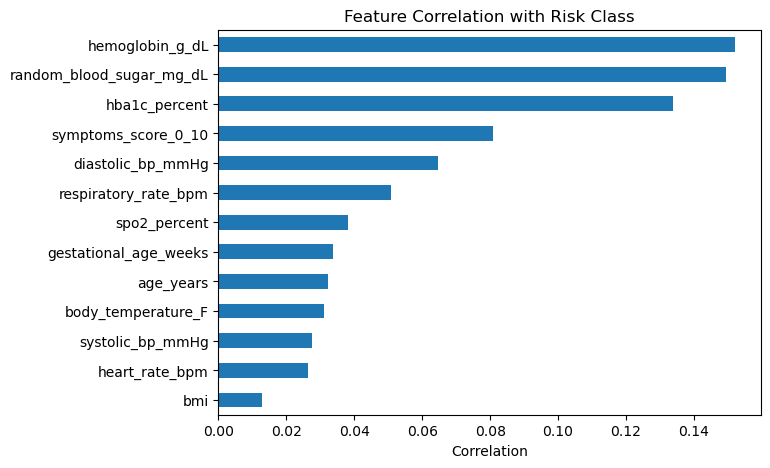

hemoglobin_g_dL             0.152130
random_blood_sugar_mg_dL    0.149478
hba1c_percent               0.133970
symptoms_score_0_10         0.080839
diastolic_bp_mmHg           0.064555
Name: risk_class, dtype: float64


In [ ]:
feature_corr = corr["risk_class"].drop("risk_class")

feature_corr.abs().sort_values().plot(kind="barh", figsize=(7,5))
plt.title("Feature Correlation with Risk Class")
plt.xlabel("Correlation")
plt.show()

print(feature_corr.abs().sort_values(ascending=False).head())